In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")


In [ ]:

df = pd.read_csv("/content/student_learning_interaction_dataset (1).csv")


df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(["student_id", "timestamp"])

df.head()


,student_id,session_id,timestamp,module_id,time_spent_minutes,pages_visited,video_watched_percent,click_events,notes_taken,forum_posts,...,attempts_taken,assignment_score,feedback_rating,days_since_last_activity,cumulative_quiz_score,learning_trend,attention_score,feedback_type,next_module_prediction,success_label
6,S0001,S0001_S7,2024-01-02 17:56:00,PHY101,32.115870,13,84.926116,16,0,1,...,1,68,3,7,526,75.14,0.27,revise_prev_topic,MATH101,1
21,S0001,S0001_S22,2024-01-04 01:52:00,ENG101,40.963298,4,61.614724,49,1,0,...,3,93,3,9,1674,76.09,0.19,revise_prev_topic,MATH101,0
11,S0001,S0001_S12,2024-01-07 07:50:00,PHY101,32.575504,5,68.138852,21,1,2,...,2,75,4,5,911,75.92,0.18,good_progress,CS101,1
18,S0001,S0001_S19,2024-01-08 02:22:00,ENG101,34.181185,12,22.836799,31,0,1,...,3,77,3,1,1453,76.47,0.13,practice_more,PHY101,1
15,S0001,S0001_S16,2024-01-15 12:44:00,SCI101,26.432550,13,83.903045,25,1,2,...,1,87,1,2,1218,76.12,0.23,pace_slow,MATH101,1


In [ ]:

df["week"] = df.groupby("student_id")["timestamp"].transform(
    lambda x: ((x - x.min()).dt.days // 7) + 1
)


In [ ]:
weekly_df = df.groupby(["student_id", "week"]).agg({
    "time_spent_minutes": "sum",
    "pages_visited": "sum",
    "video_watched_percent": "mean",
    "click_events": "sum",
    "forum_posts": "sum",
    "attempts_taken": "sum",
    "days_since_last_activity": "mean",
    "attention_score": "mean",
    "assignment_score": "mean",
    "success_label": "max"
}).reset_index()

weekly_df.head()


,student_id,week,time_spent_minutes,pages_visited,video_watched_percent,click_events,forum_posts,attempts_taken,days_since_last_activity,attention_score,assignment_score,success_label
0,S0001,1,139.835857,34,59.379123,117,4,9,5.5,0.1925,78.25,1
1,S0001,2,26.432550,13,83.903045,25,2,1,2.0,0.2300,87.00,1
2,S0001,4,17.050575,6,67.372037,32,2,1,7.0,0.1200,80.00,1
3,S0001,5,80.318216,13,72.186364,56,1,4,5.5,0.2050,77.50,1
4,S0001,6,28.758676,6,88.508520,40,1,3,8.0,0.2100,76.00,1


In [ ]:
srl_features = [
    "time_spent_minutes",
    "pages_visited",
    "video_watched_percent",
    "click_events",
    "forum_posts",
    "attempts_taken",
    "days_since_last_activity",
    "attention_score"
]

X = weekly_df[srl_features]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
weekly_df["srl_cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
weekly_df.groupby("srl_cluster")[srl_features].mean()


,time_spent_minutes,pages_visited,video_watched_percent,click_events,forum_posts,attempts_taken,days_since_last_activity,attention_score
srl_cluster,,,,,,,,
0,50.431292,13.400980,77.186907,47.344118,2.355882,3.247059,2.485294,0.216093
1,106.696827,29.112530,68.753796,104.624102,5.577813,7.111732,4.488850,0.194151
2,44.306210,11.259880,82.691908,40.390419,1.859880,2.659880,6.775250,0.230341
3,42.777952,11.317898,50.538707,45.602850,2.317008,3.091719,4.631196,0.136802


In [ ]:
cluster_labels = {
    0: "Highly Self-Regulated",
    1: "Procrastinator",
    2: "Irregular Learner",
    3: "Passive Learner"
}

weekly_df["srl_profile"] = weekly_df["srl_cluster"].map(cluster_labels)

weekly_df[["student_id", "week", "srl_profile"]].head(10)


,student_id,week,srl_profile
0,S0001,1,Procrastinator
1,S0001,2,Highly Self-Regulated
2,S0001,4,Passive Learner
3,S0001,5,Irregular Learner
4,S0001,6,Irregular Learner
5,S0001,7,Passive Learner
6,S0001,8,Irregular Learner
7,S0001,9,Highly Self-Regulated
8,S0001,10,Passive Learner
9,S0001,12,Procrastinator


In [ ]:
temporal_features = [
    "time_spent_minutes",
    "pages_visited",
    "video_watched_percent",
    "click_events",
    "forum_posts",
    "attempts_taken",
    "days_since_last_activity",
    "attention_score",
    "assignment_score"
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
weekly_df[temporal_features] = scaler.fit_transform(weekly_df[temporal_features])

In [ ]:
import numpy as np

# find maximum number of weeks any student has
max_weeks = weekly_df["week"].max()

students = weekly_df["student_id"].unique()

X_seq = []
y_seq = []

for student in students:
    student_data = weekly_df[weekly_df["student_id"] == student].sort_values("week")

    seq = student_data[temporal_features].values
    label = student_data["success_label"].max()

    # padding
    if len(seq) < max_weeks:
        padding = np.zeros((max_weeks - len(seq), len(temporal_features)))
        seq = np.vstack([seq, padding])

    X_seq.append(seq)
    y_seq.append(label)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

Sequence shape: (300, 18, 9)


In [ ]:
pip install torch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
class SRLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = SRLDataset(X_seq, y_seq)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
class SRLTransformer(nn.Module):
    def __init__(self, input_dim, model_dim=64, num_heads=4, num_layers=2):
        super().__init__()

        self.embedding = nn.Linear(input_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Linear(model_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SRLTransformer(input_dim=len(temporal_features)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss:.4f}")

Epoch 1 Loss 1.0867
Epoch 2 Loss 0.0187
Epoch 3 Loss 0.0148
Epoch 4 Loss 0.0121
Epoch 5 Loss 0.0099
Epoch 6 Loss 0.0083
Epoch 7 Loss 0.0071
Epoch 8 Loss 0.0061
Epoch 9 Loss 0.0054
Epoch 10 Loss 0.0048
Epoch 11 Loss 0.0044
Epoch 12 Loss 0.0040
Epoch 13 Loss 0.0036
Epoch 14 Loss 0.0034
Epoch 15 Loss 0.0031


In [ ]:
model.eval()

with torch.no_grad():
    preds = model(torch.tensor(X_seq, dtype=torch.float32).to(device))
    predictions = torch.argmax(preds, dim=1).cpu().numpy()

In [ ]:
student_summary = weekly_df.groupby("student_id").agg({
    "time_spent_minutes": "mean",
    "days_since_last_activity": "mean",
    "assignment_score": "mean",
    "attention_score": "mean",
    "success_label": "max"
}).reset_index()

student_summary.head()

,student_id,time_spent_minutes,days_since_last_activity,assignment_score,attention_score,success_label
0,S0001,-0.016293,0.263488,0.167398,-0.111762,1
1,S0002,0.248678,0.030910,0.045959,-0.161931,1
2,S0003,0.224304,-0.000566,-0.246006,0.362569,1
3,S0004,0.325401,-0.144649,-0.471916,-0.059218,1
4,S0005,-0.282094,-0.220322,-0.179160,-0.419460,1


In [ ]:
print(predictions.shape)

(300,)


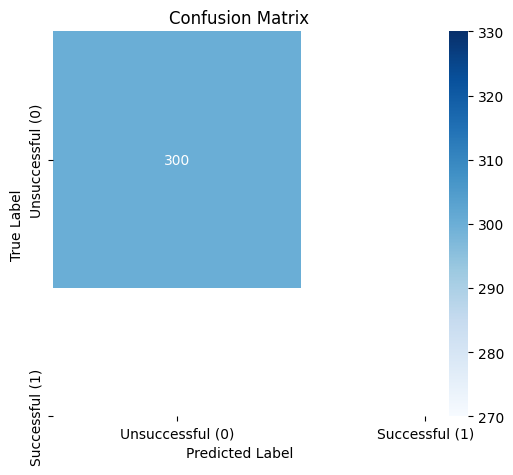

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Recalculate the confusion matrix to ensure we use the same function
cm = confusion_matrix(true_labels, pred_labels)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Unsuccessful (0)", "Successful (1)"],
            yticklabels=["Unsuccessful (0)", "Successful (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
student_summary["predicted_success"] = predictions[:len(student_summary)]
student_summary.head()


,student_id,time_spent_minutes,days_since_last_activity,assignment_score,attention_score,success_label,predicted_success
0,S0001,-0.016293,0.263488,0.167398,-0.111762,1,1
1,S0002,0.248678,0.030910,0.045959,-0.161931,1,1
2,S0003,0.224304,-0.000566,-0.246006,0.362569,1,1
3,S0004,0.325401,-0.144649,-0.471916,-0.059218,1,1
4,S0005,-0.282094,-0.220322,-0.179160,-0.419460,1,1


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

true_labels = student_summary["success_label"]
pred_labels = student_summary["predicted_success"]

print("Accuracy:", accuracy_score(true_labels, pred_labels))
print(confusion_matrix(true_labels, pred_labels))

Accuracy: 1.0
[[300]]
